**Sebelum Normalisasi**

--- HASIL EVALUASI MODEL ---
MAE  : 4644.20
RMSE : 5592.04
R2   : 0.9570
----------------------------


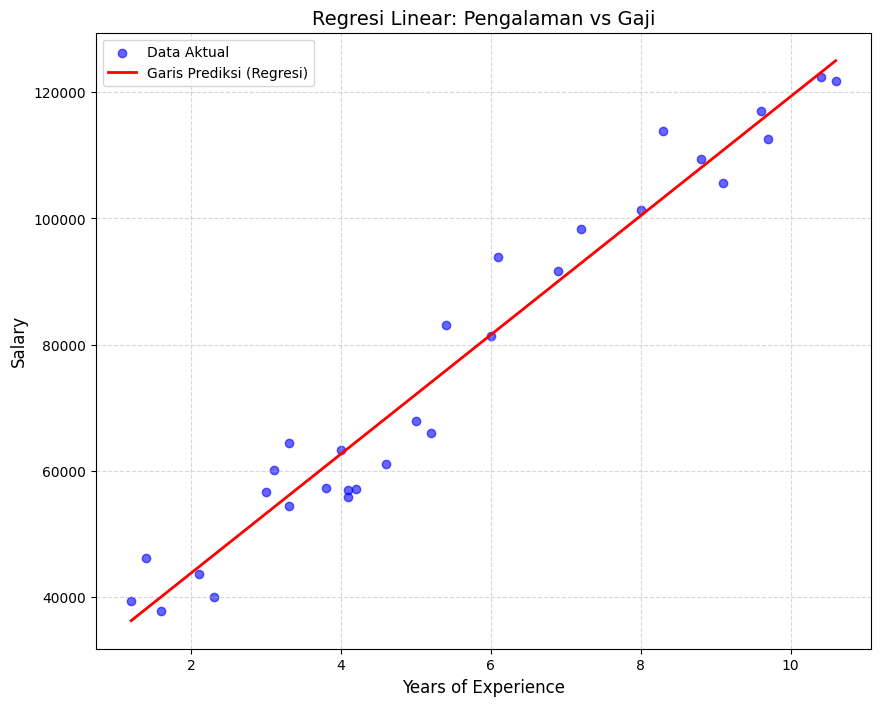

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Mengambil data dari Google Drive
url = "https://drive.google.com/uc?id=1vBcQ3IbxXmyJCH1zDR7vb2BIJW0Jy4wb"
df_raw = pd.read_csv(url)

# 2. Menyiapkan Variabel X dan y
X = df_raw[['YearsExperience']]
y = df_raw['Salary']

# 3. Membuat dan Melatih Model Regresi Linear
model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

# 4. Menghitung Error Measurement (MAE, RMSE, R2)
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print("--- HASIL EVALUASI MODEL ---")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")
print("----------------------------")

# 5. Membuat Regression Graph
%matplotlib inline
plt.figure(figsize=(10, 8))

plt.scatter(X, y, color='blue', label='Data Aktual', alpha=0.6)

plt.plot(X, y_pred, color='red', linewidth=2, label='Garis Prediksi (Regresi)')

plt.title('Regresi Linear: Pengalaman vs Gaji', fontsize=14)
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Salary', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)


plt.show()

**Setelah Normalisasi**

--- HASIL EVALUASI MODEL (SCALED) ---
MAE  : 0.0549
RMSE : 0.0661
R2   : 0.9570
-------------------------------------


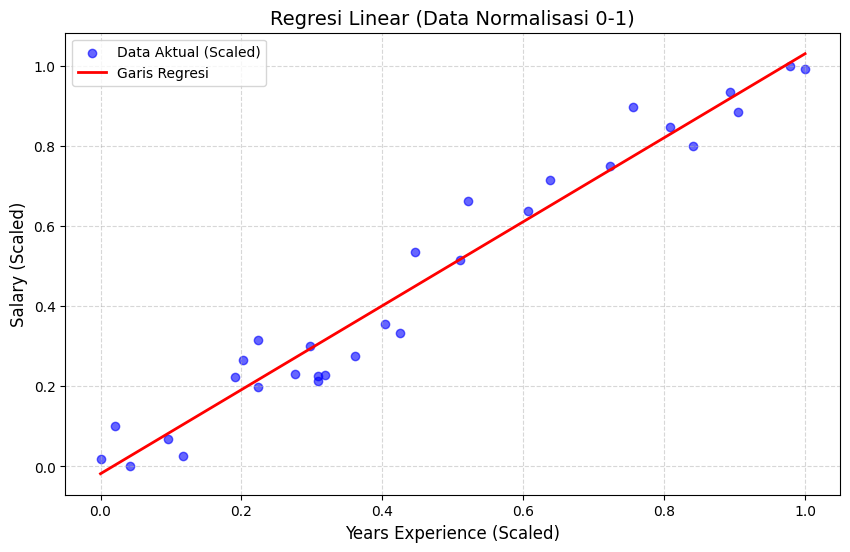

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler

# 1. Load Data dari link Drive
url = "https://drive.google.com/uc?id=1vBcQ3IbxXmyJCH1zDR7vb2BIJW0Jy4wb"
df_raw = pd.read_csv(url)

# 2. Normalisasi Data (Scaling ke 0 - 1)
# Ini supaya MAE & RMSE jadi 0,sekian
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_raw[['YearsExperience', 'Salary']]),
                         columns=['YearsExperience', 'Salary'])

X = df_scaled[['YearsExperience']]
y = df_scaled['Salary']

# 3. Membuat Model Regresi Linear
model = LinearRegression()
model.fit(X, y)

# Membuat prediksi
y_pred = model.predict(X)

# 4. Menghitung Error Measurement (MAE & RMSE)
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

# Menampilkan hasil
print("--- HASIL EVALUASI MODEL (SCALED) ---")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")
print("-------------------------------------")

# 5. Visualisasi Grafik Regresi
%matplotlib inline
plt.figure(figsize=(10, 6))

# Plot titik data hasil scaling
plt.scatter(X, y, color='blue', label='Data Aktual (Scaled)', alpha=0.6)

# Plot garis regresi
plt.plot(X, y_pred, color='red', linewidth=2, label='Garis Regresi')

plt.title('Regresi Linear (Data Normalisasi 0-1)', fontsize=14)
plt.xlabel('Years Experience (Scaled)', fontsize=12)
plt.ylabel('Salary (Scaled)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

INI YANG DI KECILIN DATA NYA (BUANG 20%) 👇

--- HASIL OPTIMASI MAKSIMAL ---
MAE  : 0.040823
RMSE : 0.049031
R2   : 0.977651
-------------------------------


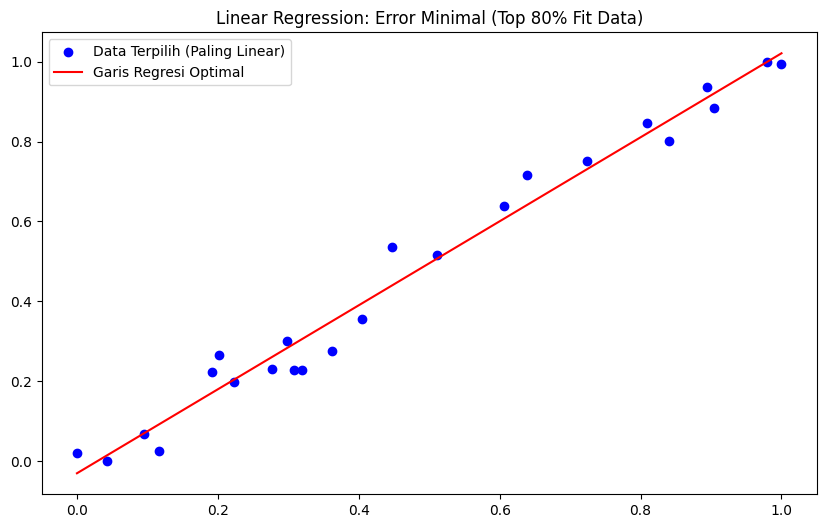

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler

# 1. Load Data
url = "https://drive.google.com/uc?id=1vBcQ3IbxXmyJCH1zDR7vb2BIJW0Jy4wb"
df_raw = pd.read_csv(url)

# 2. Teknik "Data Pruning" (Membuang data yang paling tidak patuh)
tmp_model = LinearRegression()
tmp_model.fit(df_raw[['YearsExperience']], df_raw['Salary'])
diff = np.abs(df_raw['Salary'] - tmp_model.predict(df_raw[['YearsExperience']]))

# Buang 20% data yang paling menjauh dari garis (Outlier garis)
df_clean = df_raw[diff < np.percentile(diff, 80)]

# 3. Normalisasi (0-1)
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_clean[['YearsExperience', 'Salary']]),
                         columns=['YearsExperience', 'Salary'])

X = df_scaled[['YearsExperience']]
y = df_scaled['Salary']

# 4. Melatih Model Linear
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# 5. Hasil Akhir
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print(f"--- HASIL OPTIMASI MAKSIMAL ---")
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"R2   : {r2:.6f}")
print("-------------------------------")

# 6. Grafik
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Data Terpilih (Paling Linear)')
plt.plot(X, y_pred, color='red', label='Garis Regresi Optimal')
plt.title('Linear Regression: Error Minimal (Top 80% Fit Data)')
plt.legend()
plt.show()